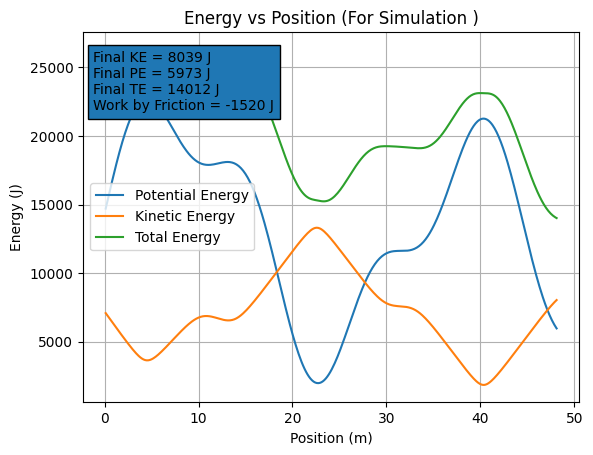

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# PARAMETERS 
# ============================================
dt = 0.01
g = 9.8
mass = 100
mu = 0.05
track_length = 50

def track(x):
    return 15 + 8*np.sin(0.2*x) + 3*np.sin(0.5*x) - 0.1*x

# ============================================
# INITIAL CONDITIONS 
# ============================================
x = 0.0
v = 12.0
t = 0.0
total_work_friction = 0

# Storage
x_vals, KE_vals, PE_vals, TE_vals = [], [], [], []

# ============================================
# SIMULATION LOOP 
# ============================================
while x < track_length - 2 and v > 0.1:
    
    y = track(x)

    #  slope step as simulation
    dx_small = 0.01
    slope = (track(x + dx_small) - track(x - dx_small)) / (2 * dx_small)
    theta = np.arctan(slope)

    #  forces
    gravity_component = -mass * g * np.sin(theta)
    normal = mass * g * abs(np.cos(theta))
    friction = mu * normal

    net_force = gravity_component - (friction * np.sign(v))

    a = net_force / mass

    #  Euler update
    v = v + a * dt
    x = x + v * dt
    t = t + dt

    # Energies
    KE = 0.5 * mass * v**2
    PE = mass * g * y
    TE = KE + PE

    # SAME friction work
    work_friction = -abs(friction * v * dt)
    total_work_friction += work_friction

    # Store
    x_vals.append(x)
    KE_vals.append(KE)
    PE_vals.append(PE)
    TE_vals.append(TE)

# ============================================
# FINAL VALUES
# ============================================
final_KE = KE_vals[-1]
final_PE = PE_vals[-1]
final_TE = TE_vals[-1]

# ============================================
# PLOT
# ============================================
plt.plot(x_vals, PE_vals, label="Potential Energy")
plt.plot(x_vals, KE_vals, label="Kinetic Energy")
plt.plot(x_vals, TE_vals, label="Total Energy")

textstr = (
    f"Final KE = {final_KE:.0f} J\n"
    f"Final PE = {final_PE:.0f} J\n"
    f"Final TE = {final_TE:.0f} J\n"
    f"Work by Friction = {total_work_friction:.0f} J"
)

plt.text(0.02, 0.95, textstr,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict())

plt.xlabel("Position (m)")
plt.ylabel("Energy (J)")
plt.title("Energy vs Position (For Simulation )")
plt.legend()
plt.grid(True)

plt.show()